# 🇵🇦 Dashboard de Indicadores Económicos de Panamá con IA
### Proyecto Integrador — Segundo Parcial

**Universidad Tecnológica de Panamá**
Facultad de Ingeniería de Sistemas Computacionales
**Gestión de la Información** — I Semestre 2026

Carlos Delgado
Adolfo López
Aldo Apicella
Yamar Camarena

---

Este notebook desarrolla, de principio a fin, un **sistema de gestión de información**
que integra las técnicas de los cinco módulos del curso para resolver una
problemática real con datos públicos de Panamá:

| # | Módulo del curso | Dónde se ve en este notebook |
|---|------------------|------------------------------|
| 1 | **Pipeline de datos** (ingesta de ≥ 2 fuentes) | Sección 2 |
| 2 | **Preprocesamiento y transformación** | Sección 3 |
| 3 | **Análisis exploratorio y visualización** | Sección 4 |
| 4 | **Machine Learning** (regresión + clustering) | Sección 5 |
| 5 | **Chatbot con RAG** conectado a los datos | Sección 6 |

El **dashboard interactivo** (Streamlit) que consume estos mismos módulos se
documenta en la Sección 7.

## 1. Problemática y objetivo

**Problemática.** Los indicadores económicos de Panamá (PIB, inflación,
desempleo, actividad del Canal, etc.) los publican distintas instituciones —el
**Instituto Nacional de Estadística y Censo (INEC)** de la **Contraloría General
de la República**, la **Autoridad del Canal de Panamá (ACP)** y organismos
internacionales como el **Banco Mundial**— en formatos y portales diferentes.
Esto hace difícil para un ciudadano, estudiante o tomador de decisiones:

1. **Reunir** los datos en un solo lugar y formato.
2. **Entender** las tendencias y los puntos de quiebre (p. ej. la pandemia de 2020).
3. **Anticipar** hacia dónde van los indicadores.
4. **Consultar** la información de forma rápida y en lenguaje natural.

**Objetivo.** Construir un sistema reproducible que:

- **Ingiera** automáticamente datos de **al menos 2 fuentes** distintas.
- Los **limpie, transforme y enriquezca** mediante un pipeline.
- Aplique **modelos predictivos** a por lo menos 2 indicadores.
- Presente todo en un **dashboard interactivo**.
- Incluya un **chatbot con RAG** que responda preguntas sobre los datos.

> **Nota sobre los datos.** La fuente del Banco Mundial se consulta **en vivo** vía
> su API pública, y el rango de años es **dinámico**: va desde 2000 hasta el año
> actual según la disponibilidad de datos (el Banco Mundial publica con 1–2 años de
> rezago). La fuente de la Contraloría/INEC/ACP puede descargarse **en tiempo real**
> si se configura una URL (`CONTRALORIA_URL`); de lo contrario usa un CSV local con
> **cifras representativas basadas en datos públicos reales** como respaldo, de modo
> que el proyecto es 100 % reproducible incluso sin conexión a internet.

## 2. Configuración del entorno

Importamos las librerías y preparamos la ruta para poder usar el paquete `src`,
que contiene la lógica del proyecto organizada en módulos:

```
src/
├── config.py              # catálogo de indicadores y parámetros
├── pipeline/
│   ├── ingesta.py          # Módulo 1A: ingesta de 2 fuentes
│   └── preprocesamiento.py # Módulo 1B: limpieza y transformación
├── ml/
│   └── modelos.py          # Módulo 3: regresión + clustering
└── rag/
    └── chatbot.py          # Módulo 5: chatbot con RAG
```

> Si ejecutas esto por primera vez, instala las dependencias con:
> `pip install -r requirements.txt`

In [1]:
# --- Librerías estándar de análisis y visualización ---
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuración visual de las gráficas.
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)


# --- Localiza la raíz del proyecto (la carpeta que contiene src/) ---
def encontrar_raiz() -> Path:
    # Sube por el árbol de carpetas hasta encontrar src/config.py.
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "src" / "config.py").exists():
            return candidato
    return Path.cwd()

RAIZ = encontrar_raiz()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
print("Raíz del proyecto:", RAIZ)

# --- Importa los módulos del proyecto ---
from src import config
from src.pipeline.ingesta import ingestar_todo
from src.pipeline.preprocesamiento import preprocesar_todo, resumen_calidad
from src.ml.modelos import entrenar_indicadores, clustering_regimenes
from src.rag.chatbot import ChatbotRAG

print(f"Proyecto: indicadores de {config.PAIS_NOMBRE} ({config.ANIO_INICIO}-{config.ANIO_FIN})")
print(f"Indicadores en el catálogo: {len(config.INDICADORES)}")

Raíz del proyecto: /Users/carlosdelgado/Documents/utp/1-semestre-2026/gestioninformacion/parcial2


Proyecto: indicadores de Panamá (2000-2026)
Indicadores en el catálogo: 9


## 3. Módulo 1 — Pipeline de datos

El pipeline tiene dos etapas: **ingesta** (traer los datos crudos de las fuentes)
y **preprocesamiento** (limpiarlos y transformarlos). Cumple el requisito de
**ingesta de al menos 2 fuentes de datos diferentes**.

### 3.1 Ingesta desde 2 fuentes

| Fuente | Mecanismo | Indicadores |
|--------|-----------|-------------|
| **Banco Mundial** | API REST (`api.worldbank.org`) | PIB, crecimiento, inflación, desempleo, IED |
| **Contraloría / INEC / ACP** | Archivo CSV (`data/raw/`) | Tránsitos e ingresos del Canal, IMAE |

La función `ingestar_todo()` descarga la Fuente 1 desde la API (con datos de
respaldo si no hay internet), carga la Fuente 2 desde el CSV, y devuelve un único
DataFrame en **formato largo (tidy)**: una fila por cada combinación
`(año, indicador)`.

In [2]:
# Ejecuta la ingesta de las 2 fuentes. Devuelve un DataFrame en formato largo.
datos_crudos = ingestar_todo()

print("\nForma del DataFrame crudo:", datos_crudos.shape)
print("Columnas:", list(datos_crudos.columns))
datos_crudos.head(8)

Iniciando ingesta de datos desde 2 fuentes...


  [ok] Datos del Banco Mundial descargados en vivo desde la API.
  [ok] Contraloría/INEC: datos locales (contraloria_panama.csv).
Ingesta completa: 231 observaciones, 9 indicadores, 26 años.

Forma del DataFrame crudo: (231, 4)
Columnas: ['anio', 'codigo', 'valor', 'fuente']


,anio,codigo,valor,fuente
0,2000,pib_crecimiento,4.209006,Banco Mundial
1,2001,pib_crecimiento,0.949908,Banco Mundial
2,2002,pib_crecimiento,2.508844,Banco Mundial
3,2003,pib_crecimiento,5.096860,Banco Mundial
4,2004,pib_crecimiento,8.175654,Banco Mundial
5,2005,pib_crecimiento,8.276183,Banco Mundial
6,2006,pib_crecimiento,9.857239,Banco Mundial
7,2007,pib_crecimiento,13.153065,Banco Mundial


In [3]:
# ¿Cuántas observaciones aporta cada fuente?
resumen_fuentes = (
    datos_crudos.groupby("fuente")
    .agg(observaciones=("valor", "size"), indicadores=("codigo", "nunique"))
    .reset_index()
)
resumen_fuentes

,fuente,observaciones,indicadores
0,Banco Mundial,156,6
1,Contraloría / ACP,50,2
2,Contraloría / INEC,25,1


### 3.2 Preprocesamiento y transformación

`preprocesar_todo()` aplica, en orden:

1. **Limpieza** — tipos correctos, sin duplicados, ordenado.
2. **Pivoteo** a formato ancho — una fila por año, una columna por indicador.
3. **Manejo de nulos** — interpolación lineal en el tiempo + relleno de extremos.
4. **Ingeniería de características** — variaciones interanuales, medias móviles de
   3 años y rezagos (lags) que servirán a los modelos.

Devuelve un diccionario con los datasets en distintas formas.

In [4]:
resultado_pipeline = preprocesar_todo(datos_crudos)

# Desempaquetamos los datasets que produce el pipeline.
df_largo    = resultado_pipeline["largo"]       # tidy limpio
df_ancho    = resultado_pipeline["ancho"]       # una columna por indicador
df_features = resultado_pipeline["features"]    # ancho + variables derivadas
reporte_nulos = resultado_pipeline["reporte_nulos"]
calidad      = resultado_pipeline["calidad"]

print("Dataset ancho:", df_ancho.shape, "| Dataset con features:", df_features.shape)
df_ancho.tail(6)

Preprocesando datos...
  [ok] Datasets guardados en /Users/carlosdelgado/Documents/utp/1-semestre-2026/gestioninformacion/parcial2/data/processed
Preprocesamiento completo: 26 años x 9 indicadores; 36 columnas con features.
Dataset ancho: (26, 10) | Dataset con features: (26, 37)


,anio,pib_crecimiento,pib_per_capita,inflacion,desempleo,pib_usd,ied,canal_transitos,canal_ingresos,imae
20,2020,-17.821230,13290.560840,-1.550275,14.663,5.705985e+10,-1.631798e+09,13369.0,2500.0,165.0
21,2021,16.467125,15509.806912,1.630703,10.177,6.739639e+10,1.833062e+09,13342.0,2900.0,191.0
22,2022,11.038548,17378.607002,2.859651,8.086,7.647930e+10,2.466522e+09,14239.0,3300.0,212.0
23,2023,7.166329,18797.193399,1.486414,6.544,8.381216e+10,2.387195e+09,14080.0,3350.0,228.0
24,2024,2.747885,19161.218850,0.693226,8.451,8.652396e+10,3.240412e+09,11240.0,4900.0,235.0
25,2025,2.747885,19161.218850,0.693226,8.360,8.652396e+10,3.240412e+09,11240.0,4900.0,235.0


**Calidad y cobertura de los datos.** Antes de modelar conviene documentar qué
tan completos están los datos de cada indicador y de qué fuente provienen.

In [5]:
print("Cobertura por indicador:")
display(calidad)

print("\nValores nulos por indicador ANTES de imputar:")
display(reporte_nulos)

Cobertura por indicador:


,codigo,nombre,fuente,unidad,observaciones,anio_min,anio_max
0,canal_ingresos,Ingresos del Canal de Panamá,Contraloría / ACP,millones USD,25,2000,2024
1,canal_transitos,Tránsitos por el Canal de Panamá,Contraloría / ACP,buques/año,25,2000,2024
2,desempleo,Tasa de desempleo,Banco Mundial,%,26,2000,2025
3,ied,Inversión Extranjera Directa,Banco Mundial,USD,25,2000,2024
4,imae,Índice Mensual de Actividad Económica (promedio),Contraloría / INEC,índice 2007=100,25,2000,2024
5,inflacion,Inflación (IPC),Banco Mundial,%,25,2000,2024
6,pib_crecimiento,PIB - Crecimiento anual,Banco Mundial,%,25,2000,2024
7,pib_per_capita,PIB per cápita,Banco Mundial,USD,25,2000,2024
8,pib_usd,PIB total,Banco Mundial,USD,25,2000,2024



Valores nulos por indicador ANTES de imputar:


,codigo,nombre,nulos,pct_nulos
0,pib_crecimiento,PIB - Crecimiento anual,1,3.8
1,pib_per_capita,PIB per cápita,1,3.8
2,inflacion,Inflación (IPC),1,3.8
3,desempleo,Tasa de desempleo,0,0.0
4,pib_usd,PIB total,1,3.8
5,ied,Inversión Extranjera Directa,1,3.8
6,canal_transitos,Tránsitos por el Canal de Panamá,1,3.8
7,canal_ingresos,Ingresos del Canal de Panamá,1,3.8
8,imae,Índice Mensual de Actividad Económica (promedio),1,3.8


**Ingeniería de características.** Para cada indicador se generaron tres variables
derivadas que capturan la *dinámica temporal* (no solo el nivel):

- `*_var`  → variación porcentual respecto al año anterior.
- `*_mm3`  → media móvil de 3 años (tendencia suavizada).
- `*_lag1` → valor del año anterior (memoria de la serie).

In [6]:
# Mostramos algunas características derivadas del PIB per cápita.
cols_demo = ["anio", "pib_per_capita", "pib_per_capita_var",
             "pib_per_capita_mm3", "pib_per_capita_lag1"]
df_features[cols_demo].tail(8)

,anio,pib_per_capita,pib_per_capita_var,pib_per_capita_mm3,pib_per_capita_lag1
18,2018,16151.327343,2.909897,15559.439420,15694.629752
19,2019,16477.906627,2.021997,16107.954574,16151.327343
20,2020,13290.560840,-19.343148,15306.598270,16477.906627
21,2021,15509.806912,16.697911,15092.758126,13290.560840
22,2022,17378.607002,12.049151,15392.991585,15509.806912
23,2023,18797.193399,8.162831,17228.535771,17378.607002
24,2024,19161.218850,1.936595,18445.673084,18797.193399
25,2025,19161.218850,0.000000,19039.877033,19161.218850


## 4. Módulo 2 — Análisis exploratorio y visualización (EDA)

Exploramos los datos limpios con estadística descriptiva y gráficas, buscando
tendencias, valores extremos y relaciones entre indicadores.

In [7]:
# Estadísticas descriptivas de los indicadores principales.
indicadores_macro = ["pib_crecimiento", "inflacion", "desempleo",
                     "pib_per_capita", "canal_transitos", "canal_ingresos"]
df_ancho[indicadores_macro].describe().round(2)

,pib_crecimiento,inflacion,desempleo,pib_per_capita,canal_transitos,canal_ingresos
count,26.00,26.00,26.00,26.00,26.00,26.00
mean,5.67,2.08,6.30,11079.16,13619.81,2233.08
std,6.14,2.25,2.28,5372.26,876.60,1122.34
min,-17.82,-1.55,3.67,3975.09,11240.00,760.00
25%,3.31,0.69,5.21,5726.03,13235.50,1332.50
50%,5.51,1.49,5.91,11669.06,13797.50,2410.00
75%,9.29,2.86,6.30,15648.42,14200.00,2690.00
max,16.47,8.76,14.66,19161.22,14700.00,4900.00


### 4.1 Evolución del crecimiento del PIB (con el desplome de 2020)

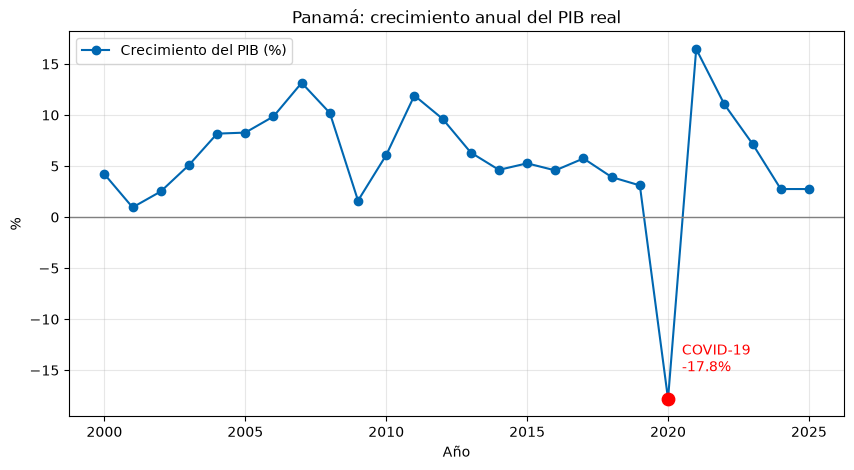

In [8]:
fig, ax = plt.subplots()
ax.plot(df_ancho["anio"], df_ancho["pib_crecimiento"],
        marker="o", color="#0067b1", label="Crecimiento del PIB (%)")
ax.axhline(0, color="gray", lw=1)
# Resaltamos el año de la pandemia.
anio_covid = 2020
val_covid = df_ancho.loc[df_ancho["anio"] == anio_covid, "pib_crecimiento"].values[0]
ax.scatter([anio_covid], [val_covid], color="red", zorder=5, s=80)
ax.annotate(f"COVID-19\n{val_covid:.1f}%", (anio_covid, val_covid),
            textcoords="offset points", xytext=(10, 20), color="red")
ax.set_title("Panamá: crecimiento anual del PIB real")
ax.set_xlabel("Año"); ax.set_ylabel("%"); ax.legend()
plt.show()

### 4.2 Inflación y desempleo

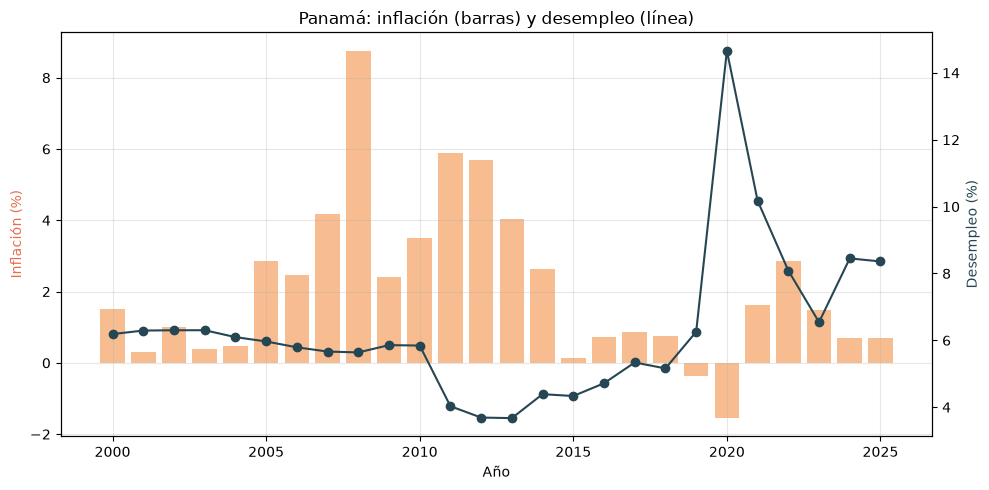

In [9]:
fig, ax1 = plt.subplots()
ax1.bar(df_ancho["anio"], df_ancho["inflacion"], color="#f4a261", alpha=0.7,
        label="Inflación (%)")
ax1.set_ylabel("Inflación (%)", color="#e76f51")
ax1.set_xlabel("Año")

ax2 = ax1.twinx()  # Segundo eje Y para el desempleo (escala distinta).
ax2.plot(df_ancho["anio"], df_ancho["desempleo"], color="#264653",
         marker="o", label="Desempleo (%)")
ax2.set_ylabel("Desempleo (%)", color="#264653")
ax2.grid(False)

ax1.set_title("Panamá: inflación (barras) y desempleo (línea)")
fig.tight_layout()
plt.show()

### 4.3 Actividad del Canal de Panamá

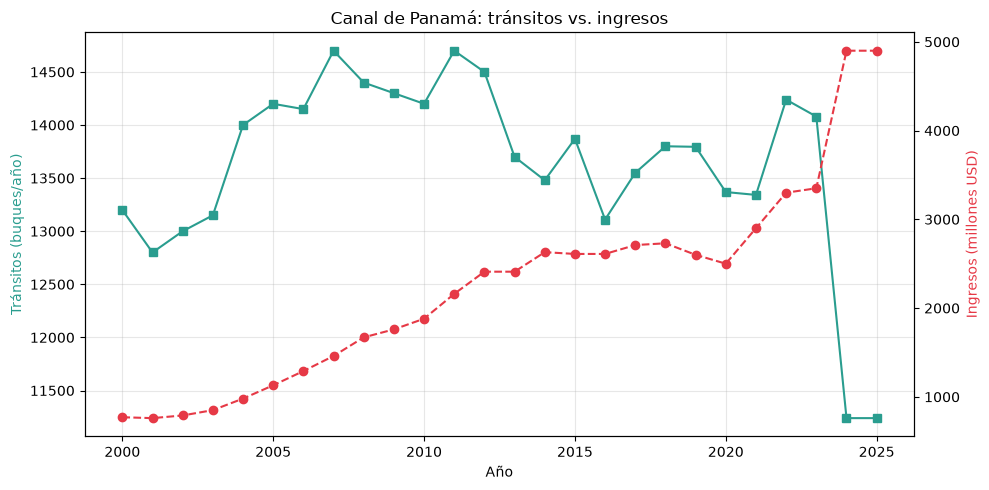

In [10]:
fig, ax1 = plt.subplots()
ax1.plot(df_ancho["anio"], df_ancho["canal_transitos"], color="#2a9d8f",
         marker="s", label="Tránsitos (buques)")
ax1.set_ylabel("Tránsitos (buques/año)", color="#2a9d8f")
ax1.set_xlabel("Año")

ax2 = ax1.twinx()
ax2.plot(df_ancho["anio"], df_ancho["canal_ingresos"], color="#e63946",
         marker="o", linestyle="--", label="Ingresos (millones USD)")
ax2.set_ylabel("Ingresos (millones USD)", color="#e63946")
ax2.grid(False)

ax1.set_title("Canal de Panamá: tránsitos vs. ingresos")
fig.tight_layout()
plt.show()

### 4.4 Matriz de correlación

¿Qué indicadores se mueven juntos? La correlación va de **-1** (se mueven en
sentidos opuestos) a **+1** (se mueven igual).

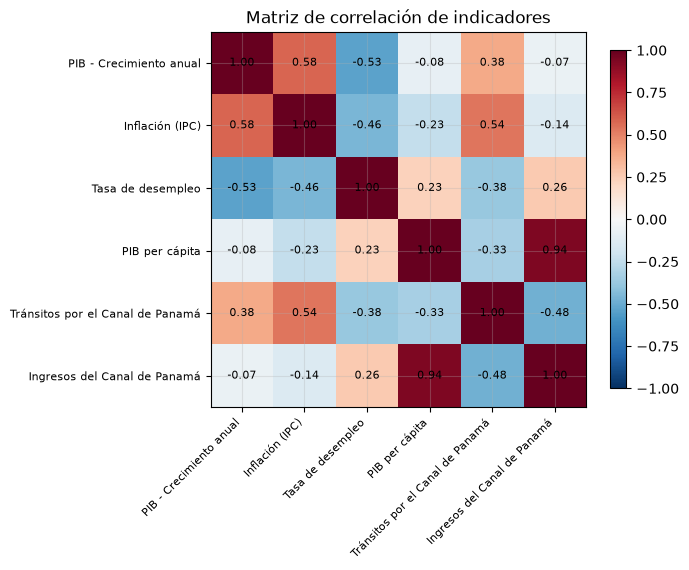

In [11]:
corr = df_ancho[indicadores_macro].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(indicadores_macro)))
ax.set_yticks(range(len(indicadores_macro)))
nombres_cortos = [config.nombre_indicador(c) for c in indicadores_macro]
ax.set_xticklabels(nombres_cortos, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(nombres_cortos, fontsize=8)
# Anota el valor de correlación en cada celda.
for i in range(len(indicadores_macro)):
    for j in range(len(indicadores_macro)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matriz de correlación de indicadores")
plt.tight_layout()
plt.show()

## 5. Módulo 3 — Machine Learning

Aplicamos **dos** técnicas de ML:

- **A) Regresión / pronóstico** de series de tiempo para predecir el futuro de
  **2 indicadores** (PIB per cápita e inflación). *(Requisito: modelo predictivo
  de al menos 2 indicadores.)*
- **B) Clustering** (KMeans) para descubrir "regímenes económicos".

### 5.1 Pronóstico (regresión)

Usamos un modelo de **regresión con características de rezago** (un modelo
autorregresivo con tendencia). La evaluación se hace con **partición temporal**:
se entrena con los años antiguos y se prueba con los últimos 5 años (nunca se usa
el futuro para entrenar). Métricas: **MAE**, **RMSE** y **R²**.

In [12]:
# Entrena y evalúa los modelos para los 2 indicadores objetivo.
resultados_ml = entrenar_indicadores(
    df_features,
    objetivos=["pib_per_capita", "inflacion"],
    n_test=5,
)

# Tabla resumen de métricas.
filas = []
for codigo, res in resultados_ml.items():
    m = res["evaluacion"]["metricas"]
    filas.append({
        "Indicador": config.nombre_indicador(codigo),
        "MAE": round(m["MAE"], 2),
        "RMSE": round(m["RMSE"], 2),
        "R2": round(m["R2"], 3),
    })
pd.DataFrame(filas)

  [PIB per cápita] MAE=2259.96  RMSE=4291.41  R2=-8.283
  [Inflación (IPC)] MAE=1.50  RMSE=1.86  R2=-4.486


,Indicador,MAE,RMSE,R2
0,PIB per cápita,2259.96,4291.41,-8.283
1,Inflación (IPC),1.50,1.86,-4.486


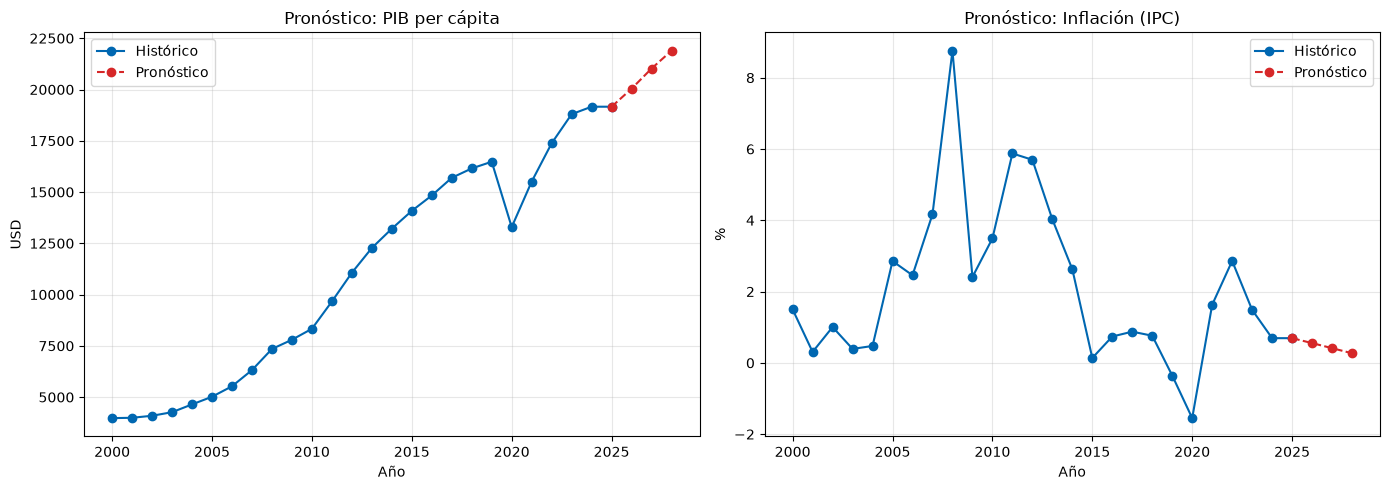

In [13]:
# Graficamos histórico + pronóstico para cada indicador objetivo.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (codigo, res) in zip(axes, resultados_ml.items()):
    df_p = res["pronostico"]
    hist = df_p[df_p["tipo"] == "histórico"]
    futu = df_p[df_p["tipo"] == "pronóstico"]
    # Conectamos el último histórico con el primer pronóstico.
    enlace = pd.concat([hist.tail(1), futu])
    ax.plot(hist["anio"], hist[codigo], marker="o", color="#0067b1", label="Histórico")
    ax.plot(enlace["anio"], enlace[codigo], marker="o", linestyle="--",
            color="#d62728", label="Pronóstico")
    ax.set_title(f"Pronóstico: {config.nombre_indicador(codigo)}")
    ax.set_xlabel("Año")
    ax.set_ylabel(config.unidad_indicador(codigo))
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# Valores numéricos del pronóstico.
for codigo, res in resultados_ml.items():
    print(f"\n>>> {config.nombre_indicador(codigo)}:")
    futu = res["pronostico"]
    print(futu[futu["tipo"] == "pronóstico"][["anio", codigo]].to_string(index=False))


>>> PIB per cápita:
 anio  pib_per_capita
 2026    20039.431025
 2027    21022.673865
 2028    21892.131464

>>> Inflación (IPC):
 anio  inflacion
 2026   0.555066
 2027   0.412514
 2028   0.269792


> **Lectura de los resultados.** El PIB per cápita, con tendencia clara, se predice
> con un error relativo razonable. La **inflación** es intrínsecamente más difícil
> de pronosticar (es ruidosa y depende de choques externos), por lo que su R²
> puede ser bajo o negativo; lo reportamos con honestidad en vez de sobre-ajustar.
> Esto es normal y esperable en series económicas cortas.

### 5.2 Clustering de regímenes económicos (KMeans)

Agrupamos los años según su comportamiento conjunto (crecimiento, inflación,
desempleo, IMAE). KMeans encuentra grupos de años "parecidos", que interpretamos
como **regímenes**: crisis, crecimiento moderado y expansión fuerte. El
**coeficiente de silueta** mide qué tan bien separados quedan los grupos.

In [15]:
clustering = clustering_regimenes(df_ancho, n_clusters=3)

print("Coeficiente de silueta:", round(clustering["silueta"], 3))
print("\nPerfil promedio de cada régimen:")
display(clustering["perfiles"])

  Clustering KMeans: 3 regímenes, coeficiente de silueta = 0.336
Coeficiente de silueta: 0.336

Perfil promedio de cada régimen:


,cluster,pib_crecimiento,inflacion,desempleo,imae,etiqueta
0,0,6.28,0.95,6.74,203.30,Crecimiento moderado
1,1,6.84,3.07,5.45,98.87,Expansión fuerte
2,2,-17.82,-1.55,14.66,165.00,Contracción / crisis


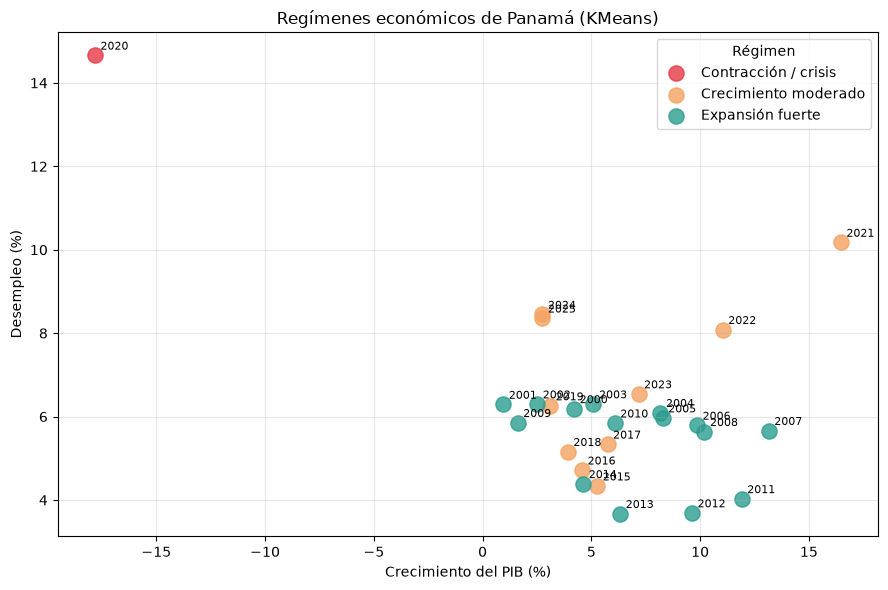

In [16]:
# Visualizamos los regímenes: crecimiento vs. desempleo, coloreado por clúster.
asign = clustering["asignaciones"]
colores = {"Contracción / crisis": "#e63946",
           "Crecimiento moderado": "#f4a261",
           "Expansión fuerte": "#2a9d8f"}

fig, ax = plt.subplots(figsize=(9, 6))
for etiqueta, grupo in asign.groupby("etiqueta"):
    ax.scatter(grupo["pib_crecimiento"], grupo["desempleo"],
               s=120, label=etiqueta, color=colores.get(etiqueta, "gray"), alpha=0.8)
    for _, fila in grupo.iterrows():
        ax.annotate(int(fila["anio"]), (fila["pib_crecimiento"], fila["desempleo"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Crecimiento del PIB (%)")
ax.set_ylabel("Desempleo (%)")
ax.set_title("Regímenes económicos de Panamá (KMeans)")
ax.legend(title="Régimen")
plt.tight_layout()
plt.show()

## 6. Módulo 5 — Chatbot con RAG

El chatbot responde preguntas en lenguaje natural sobre los indicadores. Usa
**RAG (Retrieval-Augmented Generation)**:

1. **Recuperación.** Construye una base de conocimiento de textos cortos a partir
   de NUESTROS datos (valores por año, descripciones, tendencias, pronósticos,
   eventos). Vectoriza con **TF-IDF** y, para cada pregunta, recupera los
   fragmentos más similares por **similitud de coseno**.
2. **Generación.** Pasa esos fragmentos como contexto a un modelo de lenguaje,
   pidiéndole que responda *solo* con base en ellos (así no inventa cifras). El
   chatbot soporta **3 motores** y elige automáticamente (modo `auto`):

   | Motor | Costo | Requiere |
   |-------|-------|----------|
   | **Ollama** (recomendado) | Gratis | App Ollama corriendo localmente (modelo `llama3.2`) |
   | **Claude** (`claude-opus-4-8`) | De pago | `ANTHROPIC_API_KEY` |
   | **Extractivo** | Gratis | Nada (respaldo) |

En modo `auto` prioriza lo **gratis y local**: usa **Ollama** si está corriendo;
si no, **Claude** (si hay clave); y si no, el **modo extractivo**, que arma la
respuesta con los fragmentos recuperados — por eso el chatbot **funciona siempre**.

In [17]:
# Construimos el chatbot, pasándole los datos y los resultados del ML.
chatbot = ChatbotRAG(df_ancho, resultados_ml)
print(f"Base de conocimiento: {len(chatbot.documentos)} documentos indexados.")
# Motor de generación elegido automáticamente: 'ollama', 'claude' o 'extractivo'.
print(f"Motor de generación activo: {chatbot.proveedor_activo()}")

Base de conocimiento: 176 documentos indexados.
Motor de generación activo: ollama


In [18]:
# Probamos la RECUPERACIÓN: ¿qué fragmentos encuentra para una pregunta?
pregunta_demo = "¿Cómo le fue al PIB de Panamá durante la pandemia?"
fragmentos = chatbot.recuperar(pregunta_demo, k=4)
for f in fragmentos:
    print(f"[{f['score']:.2f}] {f['texto']}")

[0.15] En 2020 la pandemia de COVID-19 provocó la mayor recesión de la historia reciente de Panamá: el PIB cayó cerca de 17.9%, el desempleo subió a alrededor de 18% y hubo deflación. La economía se recuperó con fuerza en 2021.
[0.14] Tasa de desempleo (%), fuente: Banco Mundial. Porcentaje de la fuerza laboral que está sin empleo pero buscando trabajo (estimación modelada OIT). Subió de 7.1% en 2019 a cerca de 18% en 2020 por la pandemia.
[0.14] PIB - Crecimiento anual (%), fuente: Banco Mundial. Tasa de crecimiento porcentual anual del Producto Interno Bruto real de Panamá. Mide qué tan rápido se expande o contrae la economía. Panamá tuvo una caída histórica de -17.9% en 2020 por la pandemia de COVID-19 y un fuerte rebote en 2021.
[0.09] En 2025, PIB - Crecimiento anual de Panamá fue 2.7% (%).


In [19]:
# Probamos respuestas completas (recuperación + generación).
preguntas = [
    "¿Cómo le fue al PIB de Panamá en 2020?",
    "¿Qué pasó con el desempleo durante la pandemia?",
    "¿Cuál es el pronóstico de la inflación?",
    "¿Cuántos buques transitan el Canal de Panamá?",
]
for p in preguntas:
    r = chatbot.responder(p)
    print("=" * 80)
    print("P:", p)
    print(f"[modo: {r['modo']}]")
    print(r["respuesta"])
    print()

P: ¿Cómo le fue al PIB de Panamá en 2020?
[modo: ollama]
Según los datos proporcionados, en 2020, el PIB de Panamá experimentó un crecimiento anual del -17.8%. Esto significa que el PIB disminuyó significativamente en ese año debido a la crisis económica causada por la pandemia de COVID-19.



P: ¿Qué pasó con el desempleo durante la pandemia?
[modo: ollama]
Con base en el contexto proporcionado, no se puede determinar con certeza qué pasó con el desempleo durante la pandemia, ya que no hay información específica sobre los años antes o después de 2019.

Sin embargo, podemos observar que en 2023, la tasa de desempleo volvió a caer a un nivel similar al de 2019 (6.3%), lo que sugiere que el desempleo podría haber aumentado durante la pandemia y luego disminuido una vez que se implementaron medidas para mitigar sus efectos.

Además, podemos notar que en 2024, la tasa de desempleo volvió a aumentar ligeramente (8.5%) en comparación con 2023 (6.5%), lo que podría indicar que el desempleo no se estabilizó completamente después de la pandemia.

En resumen, aunque no hay información directa sobre los efectos de la pandemia en el desempleo, podemos inferir que el desempleo aumentó durante la pandemia y luego disminuyó una vez que se implementaron medidas para mitigar sus efectos, per

P: ¿Cuál es el pronóstico de la inflación?
[modo: ollama]
Con base en el contexto proporcionado, el pronóstico de la inflación para los próximos tres años (2026, 2027 y 2028) es lo siguiente:

- Para 2026: se espera una inflación del 0.6%.
- Para 2027: se espera una inflación del 0.4%.
- Para 2028: se espera una inflación del 0.3%.

Es importante mencionar que la calidad del modelo en prueba es limitada, ya que el R2 es negativo (-4.49) y el RMSE (error medio absoluto) es de 1.86%. Esto sugiere que el modelo puede no ser muy preciso o confiable en sus pronósticos.



P: ¿Cuántos buques transitan el Canal de Panamá?
[modo: ollama]
Según los datos proporcionados, en 2024 y 2025, se registraron 11,240 buques que transitaron el Canal de Panamá. Por lo tanto, la respuesta es: 11,240 buques.



> **Cómo activar una IA generativa GRATIS (Ollama).** El modo extractivo siempre
> funciona, pero para que el chatbot redacte respuestas con una IA sin costo:
>
> ```bash
> # 1) Instala Ollama: https://ollama.com/download
> # 2) Descarga un modelo (una sola vez):
> ollama pull llama3.2
> # 3) Vuelve a ejecutar este notebook: el chatbot detecta Ollama solo
> #    y el campo "modo" de la respuesta será "ollama".
> ```
>
> Alternativa en la nube (de pago) con Claude: define `ANTHROPIC_API_KEY` y el
> chatbot usará `claude-opus-4-8` (`modo == "claude"`). El motor se elige solo:
> Ollama → Claude → extractivo.

## 7. Módulo 4 — Dashboard interactivo (Streamlit)

Todo lo anterior se integra en un **dashboard web interactivo** construido con
**Streamlit**, con un diseño profesional de tema oscuro (azul marino), tipografías
personalizadas y animaciones, que reutiliza exactamente los mismos módulos de
`src/`. Tiene cuatro pestañas:

- **Tendencias** — gráficas interactivas de los indicadores, con filtro de años y
  opción de normalizar.
- **Predicciones** — pronósticos del modelo de ML con sus métricas.
- **Análisis** — clustering de regímenes económicos.
- **Asistente** — el chatbot con RAG conversacional.

**Cómo ejecutarlo** (desde la raíz del proyecto):

```bash
streamlit run dashboard/app.py
```

Esto abre el dashboard en el navegador (por defecto en `http://localhost:8501`).

## 8. Conclusiones

- Se construyó un **pipeline de datos funcional** que ingiere **2 fuentes
  distintas** (API del Banco Mundial + CSV de la Contraloría/INEC/ACP), las limpia,
  transforma y enriquece con ingeniería de características.
- El **análisis exploratorio** muestra con claridad los grandes hitos de la
  economía panameña: el auge de los 2000, el desplome de **-17.9 %** en 2020 por
  la pandemia, la recuperación de 2021 y la desaceleración de 2024.
- Los **modelos de Machine Learning** permiten **pronosticar** el PIB per cápita y
  la inflación, y el **clustering** identifica regímenes económicos coherentes
  (crisis, crecimiento moderado, expansión).
- El **chatbot con RAG** responde preguntas sobre los datos anclando sus
  respuestas en información verificable, con **Ollama** (IA local gratis) o Claude
  como generador y un modo extractivo de respaldo.
- Todo se integra en un **dashboard interactivo** reproducible.

**Trabajo futuro:** incorporar datos mensuales/trimestrales, más fuentes (FMI,
CEPAL), modelos de series de tiempo dedicados (ARIMA, Prophet) y embeddings
vectoriales para mejorar la recuperación del chatbot.

## 9. Referencias

- **Banco Mundial — World Bank Open Data API.** https://data.worldbank.org
  (indicadores `NY.GDP.MKTP.KD.ZG`, `FP.CPI.TOTL.ZG`, `SL.UEM.TOTL.ZS`, etc.)
- **Instituto Nacional de Estadística y Censo (INEC) — Contraloría General de la
  República de Panamá.** https://www.contraloria.gob.pa/inec/
- **Autoridad del Canal de Panamá (ACP).** https://www.pancanal.com
- **Fondo Monetario Internacional (FMI)** y **CEPAL** — reportes sobre Panamá.
- **scikit-learn**, **pandas**, **Streamlit**, **Ollama** (IA local gratis) y
  **Anthropic Claude API**.

---
*Notebook del Proyecto Integrador — Gestión de la Información, UTP, I Semestre 2026.*